In [1]:
import pandas as pd
import csv
import matplotlib.pyplot as plt

In [2]:
file_path = "Freedom Indices.xlsx"
freedom_indices = pd.read_excel(file_path, sheet_name='FIW06-24')
freedom_total=pd.read_excel(file_path, sheet_name='FIW03-05')

In [3]:
freedom_indices = freedom_indices.loc[:, ~freedom_indices.columns.str.contains('^Unnamed')]
freedom_indices = freedom_indices.iloc[:, :-1]
remaining_columns = freedom_indices.columns.tolist()
remaining_columns

['Country/Territory',
 'Region',
 'C/T?',
 'Edition',
 'Status',
 'PR Rating',
 'CL Rating',
 'A',
 'B',
 'C',
 'Add Q',
 'Add A',
 'PR',
 'D',
 'E',
 'F',
 'G',
 'CL',
 'Total']

In [4]:
freedom_indices = freedom_indices.drop(columns=["Add A", "Add Q"])
bob = freedom_indices
bob

,Country/Territory,Region,C/T?,Edition,Status,PR Rating,CL Rating,A,B,C,PR,D,E,F,G,CL,Total
0,Abkhazia,Eurasia,t,2024,PF,5,5,5,8,4,17,8,5,4,5,22,39
1,Afghanistan,Asia,c,2024,NF,7,7,0,0,1,1,0,3,0,2,5,6
2,Albania,Europe,c,2024,PF,3,3,9,12,7,28,13,8,10,9,40,68
3,Algeria,Africa,c,2024,NF,6,5,3,4,3,10,6,3,6,7,22,32
4,Andorra,Europe,c,2024,F,1,1,12,15,11,38,14,11,15,15,55,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3964,Vietnam,Asia,c,2006,NF,7,5,0,1,1,2,3,2,4,8,17,19
3965,Western Sahara,Africa,t,2006,NF,7,6,0,0,0,-2,3,2,0,5,10,8
3966,Yemen,Middle East,c,2006,PF,5,5,4,6,3,13,7,3,3,5,18,31
3967,Zambia,Africa,c,2006,PF,4,4,5,11,6,22,11,8,8,7,34,56


In [5]:
# Dictionary to map current column names to their definitions
column_mapping = {
    "Country/Territory": "Location Name",
    "Region": "Region",
    "C/T?": "Country or Territory?",
    "Edition": "Edition",
    "Status": "Freedom Status",
    "PR Rating": "Political Rights Rating",
    "CL Rating": "Civil Liberties Rating",
    "A": "Electoral Process",
    "B": "Political Pluralism and Participation",
    "C": "Functioning of Government",
    "Add Q": "Additional Discretionary Question (B)",
    "Add A": "Additional Discretionary Question A",
    "PR": "Political Rights category",
    "D": "Freedom of Expression and Belief",
    "E": "Associational and Organizational Rights",
    "F": "Rule of Law",
    "G": "Personal Autonomy and Individual Rights",
    "CL": "Civil Liberties category",
    "Total": "Total"
}

# Rename the columns
freedom_indices.rename(columns=column_mapping, inplace=True)

In [6]:
#add percentage column for total out of actual summed total
total_sum = freedom_indices["Total"].sum()
freedom_indices["Total Freedom Ratio"] = freedom_indices["Total"] / 100
freedom_indices.head(5)

,Location Name,Region,Country or Territory?,Edition,Freedom Status,Political Rights Rating,Civil Liberties Rating,Electoral Process,Political Pluralism and Participation,Functioning of Government,Political Rights category,Freedom of Expression and Belief,Associational and Organizational Rights,Rule of Law,Personal Autonomy and Individual Rights,Civil Liberties category,Total,Total Freedom Ratio
0,Abkhazia,Eurasia,t,2024,PF,5,5,5,8,4,17,8,5,4,5,22,39,0.39
1,Afghanistan,Asia,c,2024,NF,7,7,0,0,1,1,0,3,0,2,5,6,0.06
2,Albania,Europe,c,2024,PF,3,3,9,12,7,28,13,8,10,9,40,68,0.68
3,Algeria,Africa,c,2024,NF,6,5,3,4,3,10,6,3,6,7,22,32,0.32
4,Andorra,Europe,c,2024,F,1,1,12,15,11,38,14,11,15,15,55,93,0.93


In [7]:
# Mapping for the conversion
freedom_status_map = {
    "PF": "Partly Free",
    "F": "Free",
    "NF": "Not Free"
}

# Applying the conversion
freedom_indices["Freedom Status"] = freedom_indices["Freedom Status"].map(freedom_status_map)
freedom_indices

,Location Name,Region,Country or Territory?,Edition,Freedom Status,Political Rights Rating,Civil Liberties Rating,Electoral Process,Political Pluralism and Participation,Functioning of Government,Political Rights category,Freedom of Expression and Belief,Associational and Organizational Rights,Rule of Law,Personal Autonomy and Individual Rights,Civil Liberties category,Total,Total Freedom Ratio
0,Abkhazia,Eurasia,t,2024,Partly Free,5,5,5,8,4,17,8,5,4,5,22,39,0.39
1,Afghanistan,Asia,c,2024,Not Free,7,7,0,0,1,1,0,3,0,2,5,6,0.06
2,Albania,Europe,c,2024,Partly Free,3,3,9,12,7,28,13,8,10,9,40,68,0.68
3,Algeria,Africa,c,2024,Not Free,6,5,3,4,3,10,6,3,6,7,22,32,0.32
4,Andorra,Europe,c,2024,Free,1,1,12,15,11,38,14,11,15,15,55,93,0.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3964,Vietnam,Asia,c,2006,Not Free,7,5,0,1,1,2,3,2,4,8,17,19,0.19
3965,Western Sahara,Africa,t,2006,Not Free,7,6,0,0,0,-2,3,2,0,5,10,8,0.08
3966,Yemen,Middle East,c,2006,Partly Free,5,5,4,6,3,13,7,3,3,5,18,31,0.31
3967,Zambia,Africa,c,2006,Partly Free,4,4,5,11,6,22,11,8,8,7,34,56,0.56


C:\Users\Shivani Murugapiran\AppData\Local\Temp\ipykernel_25972\801936113.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_year['Location Name'] = df_year['Location Name'].str.strip()


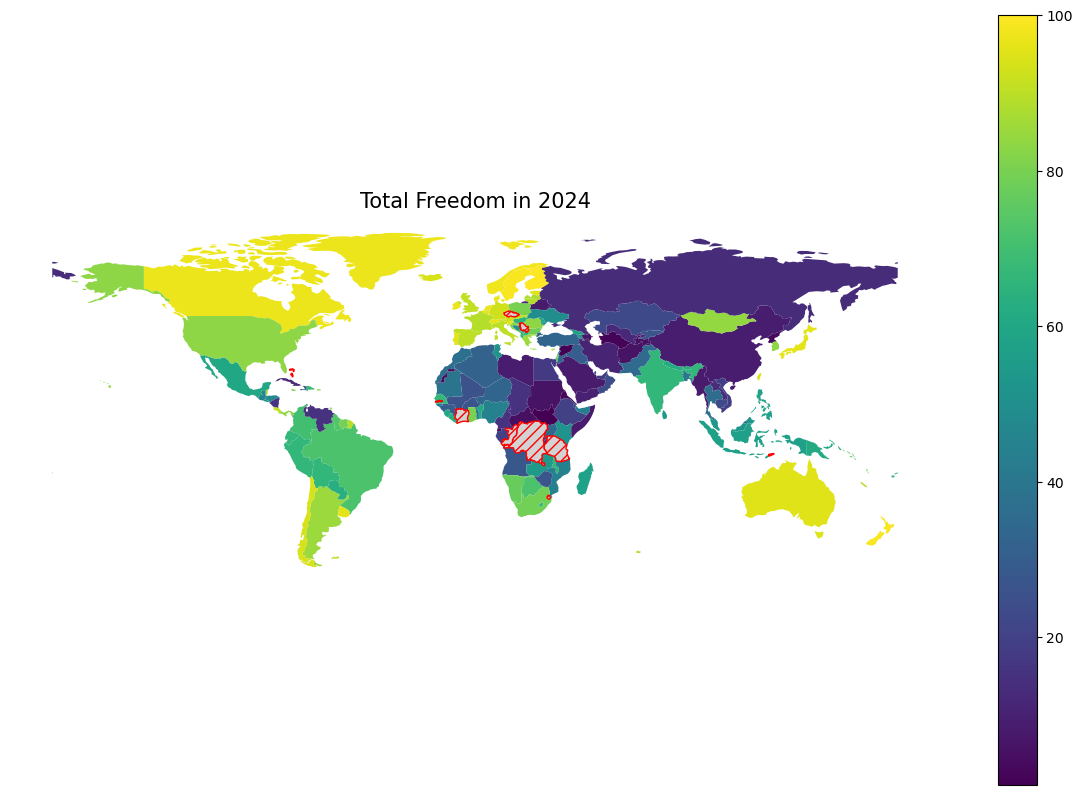

In [8]:
import plotly.express as px
import geopandas as gpd

year = 2024
indicator = 'Total'
df_year = freedom_indices[freedom_indices['Edition'] == year]

# # Ensure the country names match with the names in the geospatial data
# df_year['Location Name'] = df_year['Location Name'].str.strip()

# # Create the geospatial map
# fig = px.choropleth(df_year,
#                     locations="Location Name",
#                     locationmode='country names',
#                     color=indicator,
#                     hover_name="Location Name",
#                     color_continuous_scale=px.colors.sequential.Plasma,
#                     title=f'{indicator} in {year}')

# # Display the map
# fig.show()

df_year.loc[df_year['Location Name'] == 'United States', 'Location Name'] = 'United States of America'
world = gpd.read_file('ne_110m_admin_0_countries.shp')
world = world[world['SOVEREIGNT'] != 'Antarctica']
df_year['Location Name'] = df_year['Location Name'].str.strip()

merged = world.set_index('SOVEREIGNT').join(df_year.set_index('Location Name'))

# Plot the map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
merged.plot(column=indicator, ax=ax, legend=True, cmap='viridis', missing_kwds={
    "color": "lightgrey",
    "edgecolor": "red",
    "hatch": "///",
    "label": "Missing values"
})

ax.set_title(f'Total Freedom in {year}', fontsize=15)
ax.set_axis_off()

plt.show()

In [9]:
aList = ['Location Name'] + list(freedom_indices.columns)[5:]
aList

['Location Name',
 'Political Rights Rating',
 'Civil Liberties Rating',
 'Electoral Process',
 'Political Pluralism and Participation',
 'Functioning of Government',
 'Political Rights category',
 'Freedom of Expression and Belief',
 'Associational and Organizational Rights',
 'Rule of Law',
 'Personal Autonomy and Individual Rights',
 'Civil Liberties category',
 'Total',
 'Total Freedom Ratio']

In [10]:
import csv
from datetime import datetime
from pprint import pprint
import pandas as pd
import numpy as np

In [11]:
with open("Financial-Inclusion.csv",'r') as infile:
    text = list(csv.reader(infile))
    header = text[0]
    data = text[1:]

states = data[0:572]
states_df = pd.DataFrame(states, columns=header)
states_df = states_df[states_df["Country name"] != "Iceland"]
states_df.replace("", np.nan, inplace=True)
df_cleaned = states_df.dropna(axis=1, how='any')
regions = data[573:595]
region_df = pd.DataFrame(regions, columns=header)
region_df.replace("", np.nan, inplace=True)
df_cleaned1 = region_df.dropna(axis=1, how='any')

# 44 columns
# We liked the first 12, but I agree that we should run regression and let it decide for us!

def percent_to_decimal(percent_str):
    return float(percent_str.replace('%', '')) / 100

# Columns to exclude from conversion
exclude_cols = ['Country name', 'Country code', 'Year', 'Adult populaiton', 'Region']

# Apply the conversion to all columns except the excluded ones
for col in df_cleaned.columns:
    if col not in exclude_cols:
        df_cleaned.loc[:, col] = df_cleaned[col].apply(percent_to_decimal)

df_cleaned

,Country name,Country code,Year,Adult populaiton,Region,Account (% age 15+),Financial institution account (% age 15+),Owns a credit card (% age 15+),Owns a debit card (% age 15+),Owns a debit or credit card (% age 15+),...,"Saved at a financial institution, young (% ages 15-24)","Saved at a financial institution, older (% age 25+)","Borrowed from a formal financial institution, female (% age 15+)","Borrowed from a formal financial institution, male (% age 15+)","Borrowed from a formal financial institution, young (% ages 15-24)","Borrowed from a formal financial institution, older (% age 25+)","Borrowed from family or friends, female (% age 15+)","Borrowed from family or friends, male (% age 15+)","Borrowed from family or friends, young (% ages 15-24)","Borrowed from family or friends, older (% age 25+)"
0,Afghanistan,AFG,2011,15124473,South Asia,0.09,0.09,0.01,0.05,0.05,...,0.02,0.03,0.05,0.1,0.05,0.09,0.21,0.39,0.27,0.32
1,Afghanistan,AFG,2014,17300802,South Asia,0.1,0.1,0.01,0.02,0.02,...,0.04,0.03,0.01,0.08,0.04,0.05,0.19,0.26,0.2,0.24
2,Afghanistan,AFG,2017,19718214,South Asia,0.15,0.15,0.01,0.03,0.03,...,0.04,0.04,0.03,0.04,0.01,0.05,0.24,0.28,0.25,0.27
3,Afghanistan,AFG,2021,22647496,South Asia,0.1,0.1,0.0,0.03,0.03,...,0.0,0.02,0.01,0.03,0.02,0.02,0.64,0.57,0.59,0.61
4,Albania,ALB,2011,2258900,Europe & Central Asia (excluding high income),0.28,0.28,0.11,0.21,0.24,...,0.07,0.09,0.06,0.09,0.05,0.08,0.13,0.08,0.08,0.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,Zambia,ZMB,2021,10291819,Sub-Saharan Africa (excluding high income),0.49,0.24,0.02,0.1,0.11,...,0.05,0.1,0.06,0.08,0.04,0.08,0.38,0.49,0.41,0.44
568,Zimbabwe,ZWE,2011,7414228,Sub-Saharan Africa (excluding high income),0.4,0.4,0.06,0.28,0.29,...,0.08,0.23,0.04,0.06,0.01,0.07,0.56,0.59,0.55,0.59
569,Zimbabwe,ZWE,2014,7712326,Sub-Saharan Africa (excluding high income),0.32,0.17,0.02,0.14,0.14,...,0.03,0.06,0.04,0.04,0.02,0.06,0.55,0.56,0.52,0.57
570,Zimbabwe,ZWE,2017,8044282,Sub-Saharan Africa (excluding high income),0.55,0.28,0.01,0.22,0.22,...,0.04,0.06,0.04,0.06,0.03,0.05,0.37,0.38,0.36,0.39


In [12]:
freedom_indices.loc[:, 'Edition'] = freedom_indices['Edition'].astype(int)
df_cleaned.loc[:, 'Year'] = df_cleaned['Year'].astype(int)
freedom_score_df = freedom_indices[['Location Name', 'Edition', 'Total Freedom Ratio']]
merged_df = pd.merge(freedom_score_df, df_cleaned, left_on=['Location Name', 'Edition'], right_on=['Country name', 'Year'])
merged_df = merged_df.drop(columns='Country name')
merged_df
#merged_df.columns


,Location Name,Edition,Total Freedom Ratio,Country code,Year,Adult populaiton,Region,Account (% age 15+),Financial institution account (% age 15+),Owns a credit card (% age 15+),...,"Saved at a financial institution, young (% ages 15-24)","Saved at a financial institution, older (% age 25+)","Borrowed from a formal financial institution, female (% age 15+)","Borrowed from a formal financial institution, male (% age 15+)","Borrowed from a formal financial institution, young (% ages 15-24)","Borrowed from a formal financial institution, older (% age 25+)","Borrowed from family or friends, female (% age 15+)","Borrowed from family or friends, male (% age 15+)","Borrowed from family or friends, young (% ages 15-24)","Borrowed from family or friends, older (% age 25+)"
0,Azerbaijan,2022,0.09,AZE,2022,7732693,Europe & Central Asia (excluding high income),0.46,0.46,0.09,...,0.05,0.04,0.17,0.22,0.15,0.2,0.38,0.45,0.32,0.44
1,Botswana,2022,0.72,BWA,2022,1566095,Sub-Saharan Africa (excluding high income),0.59,0.5,0.08,...,0.18,0.17,0.08,0.12,0.06,0.11,0.27,0.35,0.41,0.28
2,Chad,2022,0.15,TCD,2022,8789428,Sub-Saharan Africa (excluding high income),0.24,0.18,0.03,...,0.06,0.09,0.08,0.09,0.07,0.09,0.41,0.46,0.42,0.44
3,Comoros,2022,0.42,COM,2022,530280,Sub-Saharan Africa (excluding high income),0.34,0.31,0.01,...,0.06,0.14,0.07,0.1,0.05,0.1,0.25,0.33,0.28,0.29
4,Eswatini,2022,0.17,SWZ,2022,725765,Sub-Saharan Africa (excluding high income),0.66,0.38,0.03,...,0.08,0.16,0.09,0.1,0.08,0.1,0.55,0.55,0.52,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508,Uruguay,2011,0.97,URY,2011,2613435,High income,0.24,0.24,0.27,...,0.03,0.06,0.14,0.16,0.04,0.17,0.06,0.07,0.06,0.07
509,Uzbekistan,2011,0.04,UZB,2011,20240648,Europe & Central Asia (excluding high income),0.23,0.23,0.03,...,0.0,0.01,0.01,0.02,0.01,0.02,0.1,0.13,0.08,0.13
510,Vietnam,2011,0.20,VNM,2011,67183392,East Asia & Pacific (excluding high income),0.21,0.21,0.01,...,0.03,0.1,0.15,0.17,0.1,0.18,0.27,0.35,0.36,0.3
511,Zambia,2011,0.58,ZMB,2011,7171836,Sub-Saharan Africa (excluding high income),0.21,0.21,0.04,...,0.06,0.15,0.08,0.04,0.02,0.09,0.41,0.42,0.37,0.44


In [13]:
politics_copy = merged_df
# politics_copy.drop(['Country code', 'Adult population'])
# politcs_copy.groupby(['Region', 'Year']).sum()

merged_stuff = politics_copy.drop(['Edition', 'Country code', 'Adult populaiton', 'Location Name'], axis=1)
#politcs_copy.groupby(['Region', 'Year']).sum()
new = merged_stuff.groupby(['Region', 'Year']).mean()
merged_stuff

,Total Freedom Ratio,Year,Region,Account (% age 15+),Financial institution account (% age 15+),Owns a credit card (% age 15+),Owns a debit card (% age 15+),Owns a debit or credit card (% age 15+),Saved at a financial institution (% age 15+),Borrowed from a formal financial institution (% age 15+),...,"Saved at a financial institution, young (% ages 15-24)","Saved at a financial institution, older (% age 25+)","Borrowed from a formal financial institution, female (% age 15+)","Borrowed from a formal financial institution, male (% age 15+)","Borrowed from a formal financial institution, young (% ages 15-24)","Borrowed from a formal financial institution, older (% age 25+)","Borrowed from family or friends, female (% age 15+)","Borrowed from family or friends, male (% age 15+)","Borrowed from family or friends, young (% ages 15-24)","Borrowed from family or friends, older (% age 25+)"
0,0.09,2022,Europe & Central Asia (excluding high income),0.46,0.46,0.09,0.38,0.38,0.04,0.19,...,0.05,0.04,0.17,0.22,0.15,0.2,0.38,0.45,0.32,0.44
1,0.72,2022,Sub-Saharan Africa (excluding high income),0.59,0.5,0.08,0.3,0.32,0.17,0.1,...,0.18,0.17,0.08,0.12,0.06,0.11,0.27,0.35,0.41,0.28
2,0.15,2022,Sub-Saharan Africa (excluding high income),0.24,0.18,0.03,0.05,0.06,0.08,0.08,...,0.06,0.09,0.08,0.09,0.07,0.09,0.41,0.46,0.42,0.44
3,0.42,2022,Sub-Saharan Africa (excluding high income),0.34,0.31,0.01,0.03,0.04,0.11,0.08,...,0.06,0.14,0.07,0.1,0.05,0.1,0.25,0.33,0.28,0.29
4,0.17,2022,Sub-Saharan Africa (excluding high income),0.66,0.38,0.03,0.25,0.26,0.14,0.1,...,0.08,0.16,0.09,0.1,0.08,0.1,0.55,0.55,0.52,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508,0.97,2011,High income,0.24,0.24,0.27,0.16,0.31,0.06,0.15,...,0.03,0.06,0.14,0.16,0.04,0.17,0.06,0.07,0.06,0.07
509,0.04,2011,Europe & Central Asia (excluding high income),0.23,0.23,0.03,0.2,0.21,0.01,0.01,...,0.0,0.01,0.01,0.02,0.01,0.02,0.1,0.13,0.08,0.13
510,0.20,2011,East Asia & Pacific (excluding high income),0.21,0.21,0.01,0.15,0.15,0.08,0.16,...,0.03,0.1,0.15,0.17,0.1,0.18,0.27,0.35,0.36,0.3
511,0.58,2011,Sub-Saharan Africa (excluding high income),0.21,0.21,0.04,0.16,0.16,0.12,0.06,...,0.06,0.15,0.08,0.04,0.02,0.09,0.41,0.42,0.37,0.44


C:\Users\Shivani Murugapiran\AppData\Local\Temp\ipykernel_25972\201262646.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_year[indicator] = pd.to_numeric(df_year[indicator], errors='coerce')
C:\Users\Shivani Murugapiran\AppData\Local\Temp\ipykernel_25972\201262646.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_year['Location Name'] = df_year['Location Name'].str.strip()


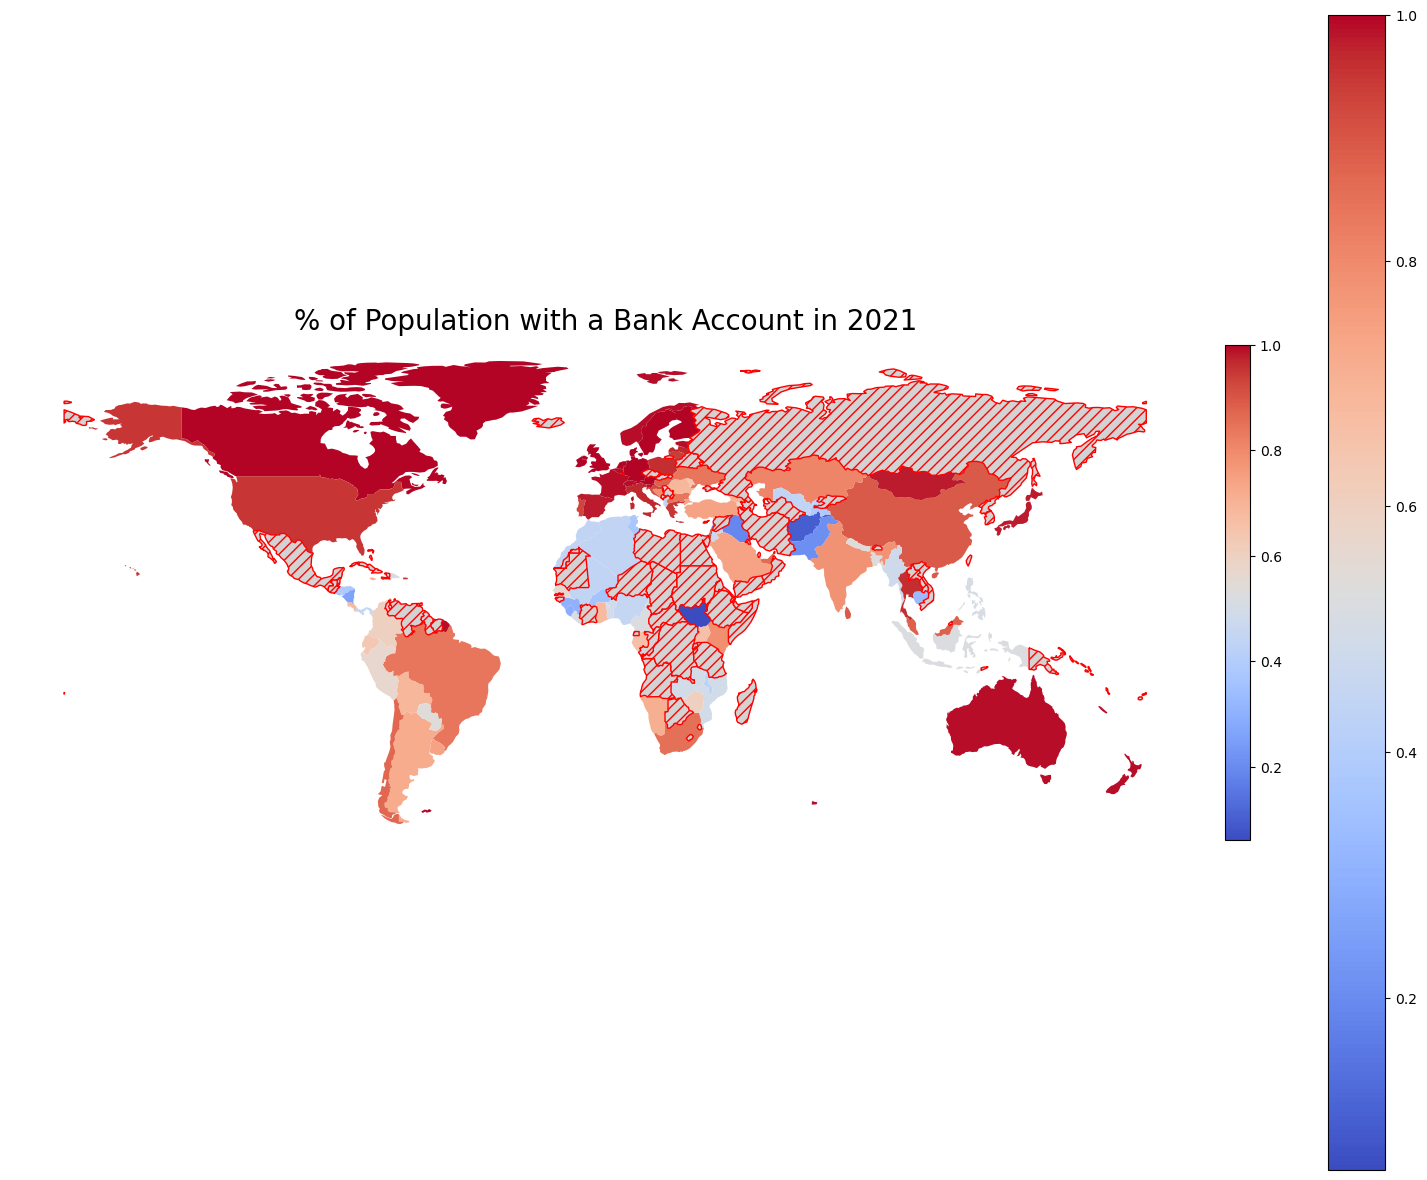

In [14]:
import matplotlib.colors as mcolors

year = 2021
indicator = 'Account (% age 15+)'
df_year = merged_df[merged_df['Edition'] == year]

# # Ensure the country names match with the names in the geospatial data
# df_year['Location Name'] = df_year['Location Name'].str.strip()

# # Create the geospatial map
# fig = px.choropleth(df_year,
#                     locations="Location Name",
#                     locationmode='country names',
#                     color=indicator,
#                     hover_name="Location Name",
#                     color_continuous_scale=px.colors.sequential.Plasma,
#                     title=f'{indicator} in {year}')

# # Display the map
# fig.show()

df_year.loc[df_year['Location Name'] == 'United States', 'Location Name'] = 'United States of America'
df_year[indicator] = pd.to_numeric(df_year[indicator], errors='coerce')

world = gpd.read_file('ne_110m_admin_0_countries.shp')
world = world[world['SOVEREIGNT'] != 'Antarctica']
df_year['Location Name'] = df_year['Location Name'].str.strip()

merged = world.set_index('SOVEREIGNT').join(df_year.set_index('Location Name'))

fig, ax = plt.subplots(1, 1, figsize=(20, 15))
cmap = plt.get_cmap('coolwarm')  # Change colormap to 'coolwarm'
norm = mcolors.Normalize(vmin=merged[indicator].min(), vmax=merged[indicator].max())

# Plot the merged GeoDataFrame
merged.plot(column=indicator, ax=ax, legend=True, cmap=cmap, norm=norm, missing_kwds={
    "color": "lightgrey",
    "edgecolor": "red",
    "hatch": "///",
    "label": "Missing values"
})

# Add title and other plot customizations
ax.set_title(f'% of Population with a Bank Account in {year}', fontsize=20)
ax.set_axis_off()

# Customize the legend
cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar.set_array(merged[indicator])
cbar.set_clim(vmin=merged[indicator].min(), vmax=merged[indicator].max())
fig.colorbar(cbar, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)

# Show the plot
plt.show()


In [15]:
new

Total Freedom Ratio  \
Region                                             Year                        
East Asia & Pacific (excluding high income)        2011             0.460000   
                                                   2014             0.452222   
                                                   2017             0.430000   
                                                   2021             0.426250   
                                                   2022             0.190000   
Europe & Central Asia (excluding high income)      2011             0.497368   
                                                   2014             0.511667   
                                                   2017             0.465789   
                                                   2021             0.516000   
                                                   2022             0.090000   
High income                                        2011             0.831220   
                                                   2014             0.858293   
                                                   2017             0.849268   
                                                   2021             0.867027   
Latin America & Caribbean (excluding high income)  2011             0.682353   
                                                   2014             0.690000   
                                                   2017             0.655625   
                                                   2021             0.678571   
                                                   2022             0.555000   
Middle East & North Africa (excluding high income) 2011             0.360000   
                                                   2014             0.410000   
                                                   2017             0.392857   
                                                   2021             0.410000   
South Asia                                         2011             0.496667   
                                                   2014             0.492857   
                                                   2017             0.484286   
                                                   2021             0.470000   
Sub-Saharan Africa (excluding high income)         2011             0.498485   
                                                   2014             0.480000   
                                                   2017             0.502121   
                                                   2021             0.495000   
                                                   2022             0.421111   

                                                        Account (% age 15+)  \
Region                                             Year                       
East Asia & Pacific (excluding high income)        2011             0.44125   
                                                   2014            0.525556   
                                                   2017            0.557778   
                                                   2021             0.69375   
                                                   2022                0.56   
Europe & Central Asia (excluding high income)      2011            0.379474   
                                                   2014            0.483889   
                                                   2017            0.566316   
                                                   2021            0.679333   
                                                   2022                0.46   
High income                                        2011            0.841707   
                                                   2014             0.89439   
                                                   2017            0.915366   
                                                   2021            0.954324   
Latin America & Caribbean (excluding high income)  2011            0.311

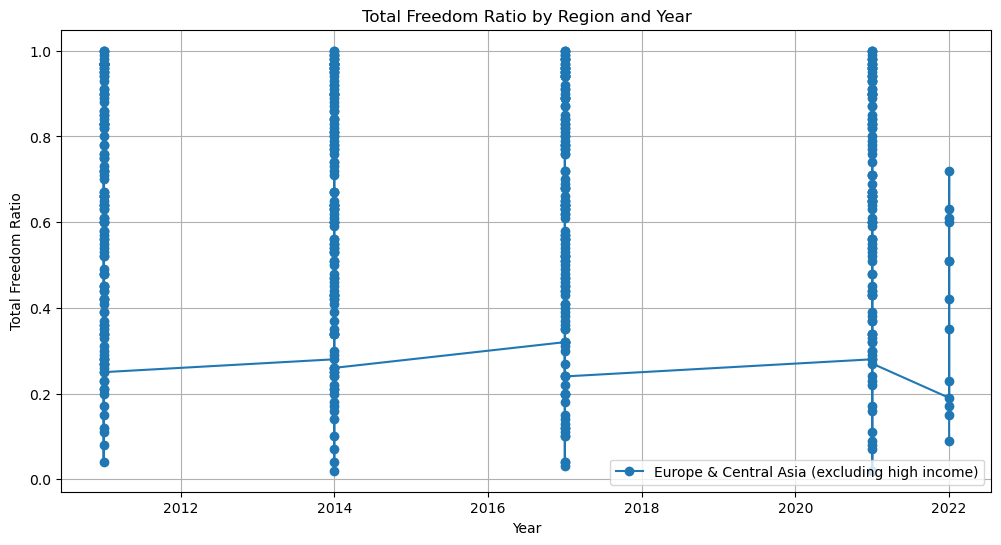

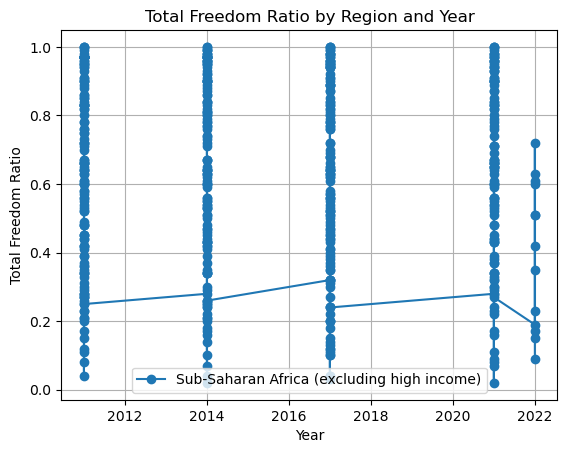

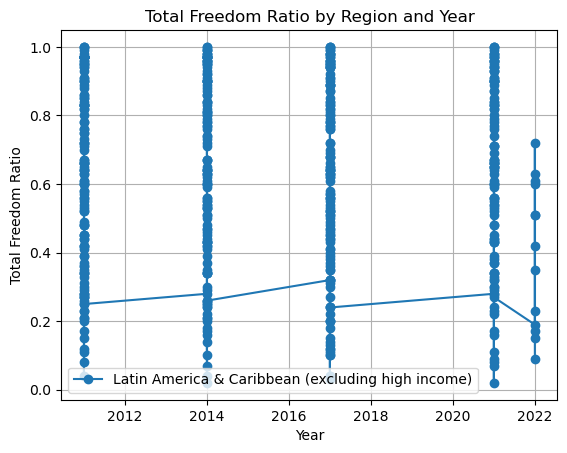

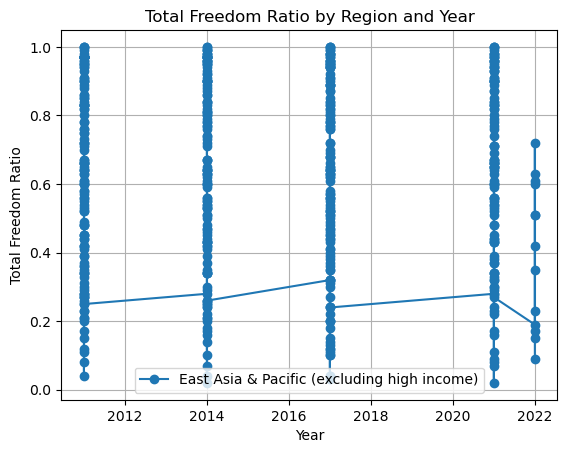

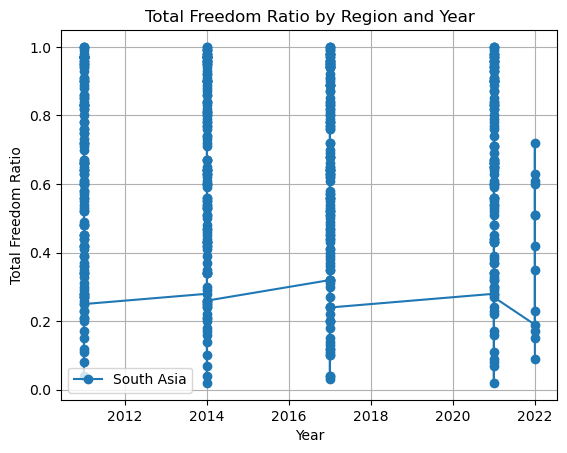

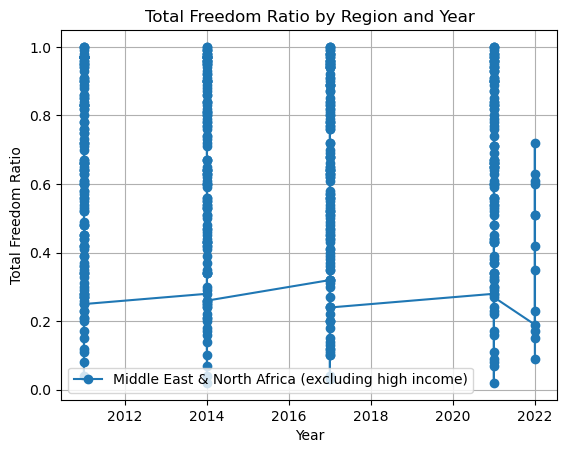

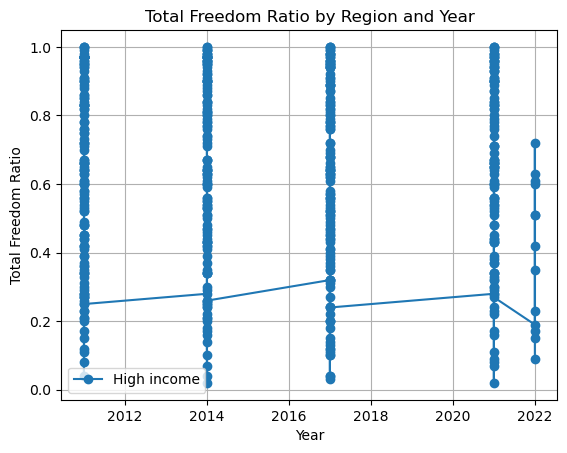

In [16]:
plt.figure(figsize=(12, 6))

for region in merged_stuff['Region'].unique():
    region_data = merged_stuff[merged_stuff['Region'] == region]
    plt.plot(merged_stuff['Year'], merged_stuff['Total Freedom Ratio'], marker='o', label=region)

    plt.xlabel('Year')
    plt.ylabel('Total Freedom Ratio')
    plt.title('Total Freedom Ratio by Region and Year')
    plt.legend()
    plt.grid(True)
    plt.show()

In [17]:
merged_df = merged_df.groupby(['Location Name', 'Year']).sum()
merged_df

Edition  Total Freedom Ratio Country code Adult populaiton  \
Location Name Year                                                              
Afghanistan   2011    2011                 0.25          AFG         15124473   
              2014    2014                 0.26          AFG         17300802   
              2017    2017                 0.24          AFG         19718214   
              2021    2021                 0.27          AFG         22647496   
Albania       2011    2011                 0.66          ALB          2258900   
...                    ...                  ...          ...              ...   
Zambia        2021    2021                 0.52          ZMB         10291819   
Zimbabwe      2011    2011                 0.21          ZWE          7414228   
              2014    2014                 0.28          ZWE          7712326   
              2017    2017                 0.32          ZWE          8044282   
              2021    2021                 0.28          ZWE          8633711   

                                                           Region  \
Location Name Year                                                  
Afghanistan   2011                                     South Asia   
              2014                                     South Asia   
              2017                                     South Asia   
              2021                                     South Asia   
Albania       2011  Europe & Central Asia (excluding high income)   
...                                                           ...   
Zambia        2021     Sub-Saharan Africa (excluding high income)   
Zimbabwe      2011     Sub-Saharan Africa (excluding high income)   
              2014     Sub-Saharan Africa (excluding high income)   
              2017     Sub-Saharan Africa (excluding high income)   
              2021     Sub-Saharan Africa (excluding high income)   

                   Account (% age 15+)  \
Location Name Year                       
Afghanistan   2011                0.09   
              2014                 0.1   
              2017                0.15   
              2021                 0.1   
Albania       2011                0.28   
...                                ...   
Zambia        2021                0.49   
Zimbabwe      2011                 0.4   
              2014                0.32   
              2017                0.55   
              2021                 0.6   

                   Financial institution account (% age 15+)  \
Location Name Year                                             
Afghanistan   2011                                      0.09   
              2014                                       0.1   
              2017                                      0.15   
              2021                                       0.1   
Albania       2011                                      0.28   
...                                                      ...   
Zambia        2021                                      0.24   
Zimbabwe      2011                                       0.4   
              2014                                      0.17   
              2017                                      0.28   
              2021                                      0.29   

                   Owns a credit card (% age 15+)  \
Location Name Year                                  
Afghanistan   2011                           0.01   
              2014                           0.01   
              2017                           0.01   
              2021                            0.0   
Albania       2011                           0.11   
...                                           ...   
Zambia        2021                           0.02   
Zimbabwe      2011                           0.06   
              2014                           0.02   
              2017                           0.01   
              2021                            0.0  

In [18]:
y_axis = merged_df.iloc[:, 5:]
import statsmodels.api as sm
dep_var = list(y_axis.columns)
X = merged_df['Total Freedom Ratio']
X = sm.add_constant(X)
X = X.apply(pd.to_numeric, errors='coerce').dropna()

results_list = []

for y_var in dep_var:
    Y = merged_df[y_var]
    Y = pd.to_numeric(Y, errors='coerce').dropna()
    
    common_index = X.index.intersection(Y.index)
    X_common = X.loc[common_index]
    Y_common = Y.loc[common_index]
    
    if len(X_common) == 0 or len(Y_common) == 0:
        print(f"Skipping {y_var} due to insufficient data after cleaning.")
        continue
    
    model = sm.OLS(Y_common, X_common).fit()
    
    r_squared = model.rsquared
    p_value = model.f_pvalue  # Overall model p-value
    coefficients = model.params
    p_values = model.pvalues
    
    result = {
        'Dependent Variable': y_var,
        'R-squared': r_squared,
        'Overall model p-value': p_value,
    }
    
    for idx in range(len(coefficients)):
        result[f'Coef_{idx}'] = coefficients.iloc[idx]
        result[f'p-value_{idx}'] = p_values.iloc[idx]
    
    results_list.append(result)

results_df = pd.DataFrame(results_list)
results_df.sort_values('R-squared', ascending=False)

,Dependent Variable,R-squared,Overall model p-value,Coef_0,p-value_0,Coef_1,p-value_1
24,"Owns a debit or credit card, female (% age 15+)",0.417933,4.857984e-62,-0.074771,6.416860e-03,0.775101,4.857984e-62
12,"Financial institution account, female (% age 15+)",0.410855,1.074804e-60,0.051605,5.825308e-02,0.760237,1.074804e-60
4,Owns a debit or credit card (% age 15+),0.394925,1.000390e-57,-0.026563,3.326295e-01,0.740957,1.000390e-57
8,"Account, female (% age 15+)",0.394846,1.034447e-57,0.104744,8.195998e-05,0.713473,1.034447e-57
20,"Owns a debit card, female (% age 15+)",0.391138,4.950888e-57,-0.072007,8.474571e-03,0.731216,4.950888e-57
27,"Owns a debit or credit card, older (% age 25+)",0.385307,5.693601e-56,-0.002947,9.154693e-01,0.735767,5.693601e-56
1,Financial institution account (% age 15+),0.380770,3.749168e-55,0.115544,1.984838e-05,0.704382,3.749168e-55
26,"Owns a debit or credit card, young (% ages 15-24)",0.376663,2.041243e-54,-0.066775,1.233480e-02,0.692075,2.041243e-54
25,"Owns a debit or credit card, male (% age 15+)",0.371654,1.588248e-53,0.018594,5.023099e-01,0.713235,1.588248e-53
19,"Owns a credit card, older (% age 25+)",0.370850,2.203666e-53,-0.104389,7.377541e-08,0.491343,2.203666e-53


In [19]:
top_R = results_df.sort_values('R-squared', ascending=False)[:21] #Selecting all indicators with a R^2 value greater than 0.35
top_R

,Dependent Variable,R-squared,Overall model p-value,Coef_0,p-value_0,Coef_1,p-value_1
24,"Owns a debit or credit card, female (% age 15+)",0.417933,4.857984e-62,-0.074771,6.416860e-03,0.775101,4.857984e-62
12,"Financial institution account, female (% age 15+)",0.410855,1.074804e-60,0.051605,5.825308e-02,0.760237,1.074804e-60
4,Owns a debit or credit card (% age 15+),0.394925,1.000390e-57,-0.026563,3.326295e-01,0.740957,1.000390e-57
8,"Account, female (% age 15+)",0.394846,1.034447e-57,0.104744,8.195998e-05,0.713473,1.034447e-57
20,"Owns a debit card, female (% age 15+)",0.391138,4.950888e-57,-0.072007,8.474571e-03,0.731216,4.950888e-57
27,"Owns a debit or credit card, older (% age 25+)",0.385307,5.693601e-56,-0.002947,9.154693e-01,0.735767,5.693601e-56
1,Financial institution account (% age 15+),0.380770,3.749168e-55,0.115544,1.984838e-05,0.704382,3.749168e-55
26,"Owns a debit or credit card, young (% ages 15-24)",0.376663,2.041243e-54,-0.066775,1.233480e-02,0.692075,2.041243e-54
25,"Owns a debit or credit card, male (% age 15+)",0.371654,1.588248e-53,0.018594,5.023099e-01,0.713235,1.588248e-53
19,"Owns a credit card, older (% age 25+)",0.370850,2.203666e-53,-0.104389,7.377541e-08,0.491343,2.203666e-53


In [20]:
top_R['Weight'] = top_R['R-squared'] / top_R['R-squared'].sum()
top_R.sort_values('R-squared', ascending=False)

,Dependent Variable,R-squared,Overall model p-value,Coef_0,p-value_0,Coef_1,p-value_1,Weight
24,"Owns a debit or credit card, female (% age 15+)",0.417933,4.857984e-62,-0.074771,6.416860e-03,0.775101,4.857984e-62,0.052916
12,"Financial institution account, female (% age 15+)",0.410855,1.074804e-60,0.051605,5.825308e-02,0.760237,1.074804e-60,0.052020
4,Owns a debit or credit card (% age 15+),0.394925,1.000390e-57,-0.026563,3.326295e-01,0.740957,1.000390e-57,0.050003
8,"Account, female (% age 15+)",0.394846,1.034447e-57,0.104744,8.195998e-05,0.713473,1.034447e-57,0.049993
20,"Owns a debit card, female (% age 15+)",0.391138,4.950888e-57,-0.072007,8.474571e-03,0.731216,4.950888e-57,0.049523
27,"Owns a debit or credit card, older (% age 25+)",0.385307,5.693601e-56,-0.002947,9.154693e-01,0.735767,5.693601e-56,0.048785
1,Financial institution account (% age 15+),0.380770,3.749168e-55,0.115544,1.984838e-05,0.704382,3.749168e-55,0.048211
26,"Owns a debit or credit card, young (% ages 15-24)",0.376663,2.041243e-54,-0.066775,1.233480e-02,0.692075,2.041243e-54,0.047691
25,"Owns a debit or credit card, male (% age 15+)",0.371654,1.588248e-53,0.018594,5.023099e-01,0.713235,1.588248e-53,0.047057
19,"Owns a credit card, older (% age 25+)",0.370850,2.203666e-53,-0.104389,7.377541e-08,0.491343,2.203666e-53,0.046955


In [21]:
merged_df['Weighted_Average'] = 0
for index, row in top_R.iterrows():
    metric = row['Dependent Variable']
    weight = row['Weight']
    merged_df['Weighted_Average'] += merged_df[metric] * weight

top_R['Weight'].sum()

1.0000000000000002

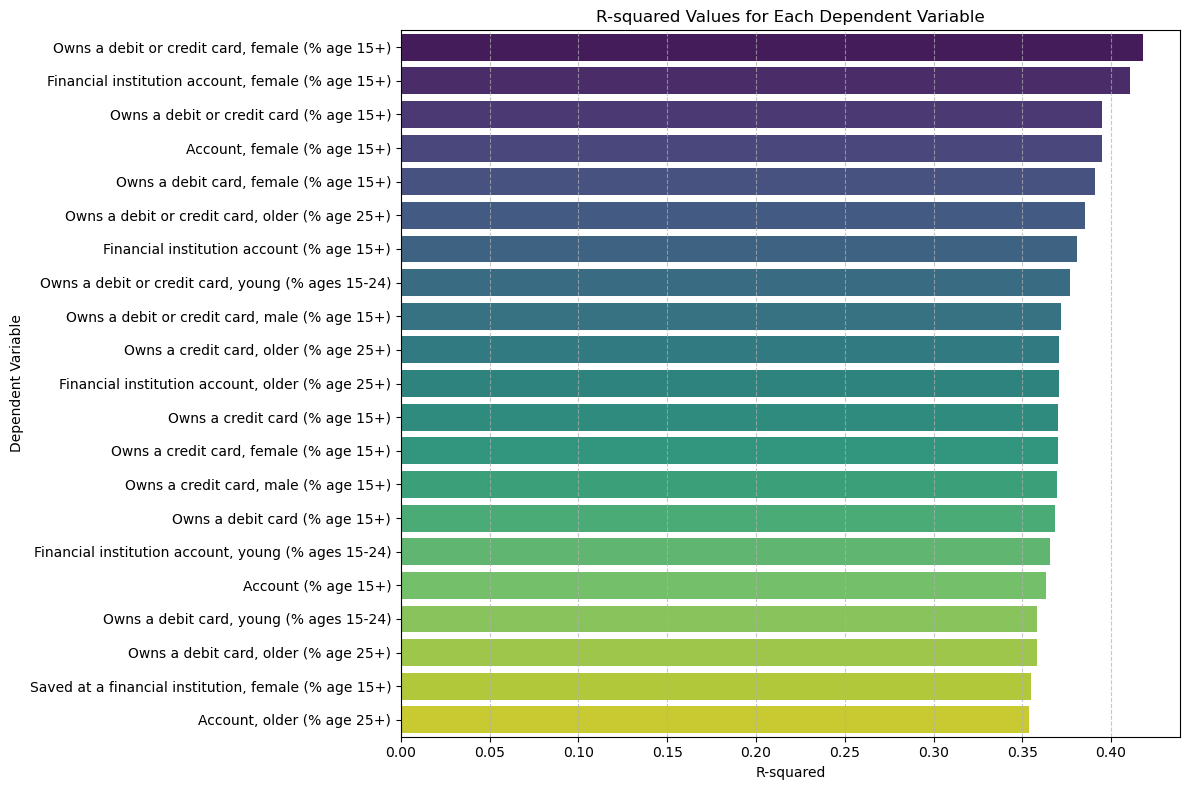

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

r_squared_df = top_R[['Dependent Variable', 'R-squared']]

plt.figure(figsize=(12, 8))
sns.barplot(
    data=r_squared_df,
    x='R-squared',
    y='Dependent Variable',
    palette='viridis'
)

plt.xlabel('R-squared')
plt.ylabel('Dependent Variable')
plt.title('R-squared Values for Each Dependent Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

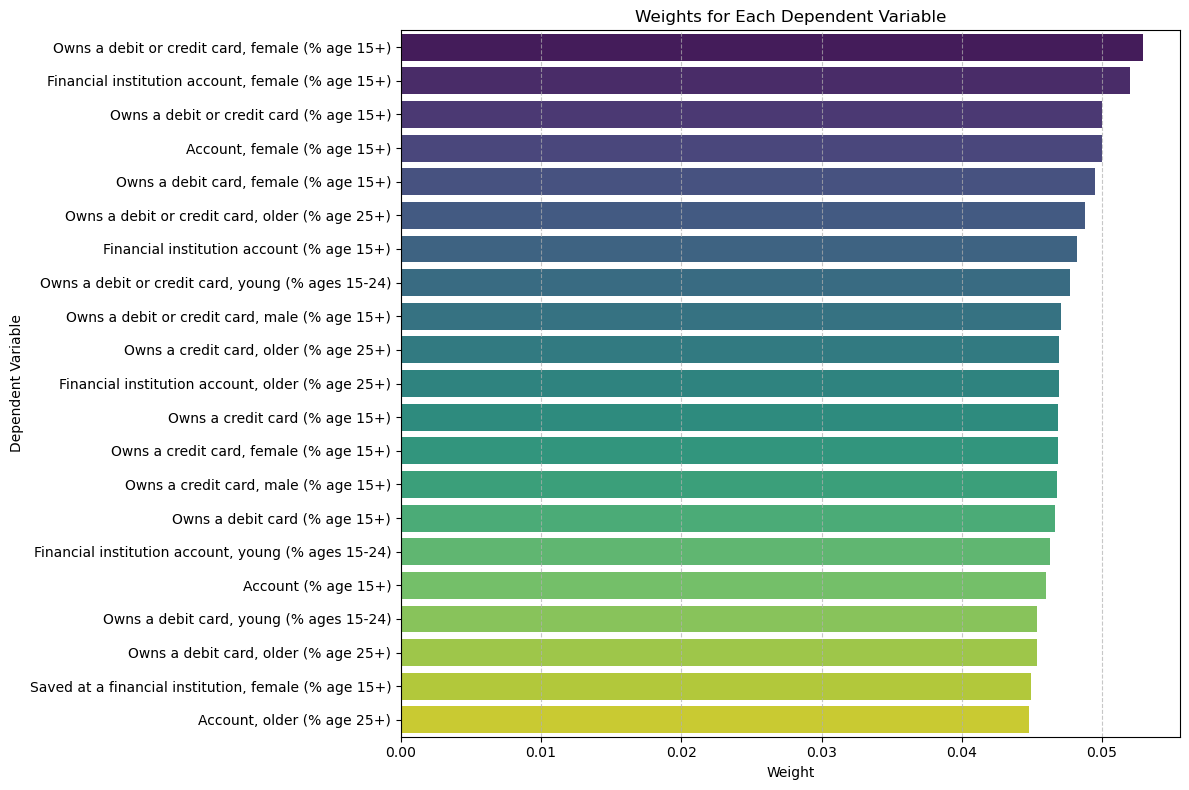

In [23]:
weights_df = top_R[['Dependent Variable', 'Weight']]

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(
    data=weights_df,
    x='Weight',
    y='Dependent Variable',
    palette='viridis'
)

plt.xlabel('Weight')
plt.ylabel('Dependent Variable')
plt.title('Weights for Each Dependent Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()


In [24]:
merged_df

merged_df.to_csv('step1final.csv')

In [25]:
# Interpretation!

#the weighted average gives a single value that encapsulates the overall level of financial inclusion
#If Location A has a higher weighted average than Location B, it means that, 
#considering all metrics of financial inclusion and their respective importance, Location A is more financially inclusive than Location B.


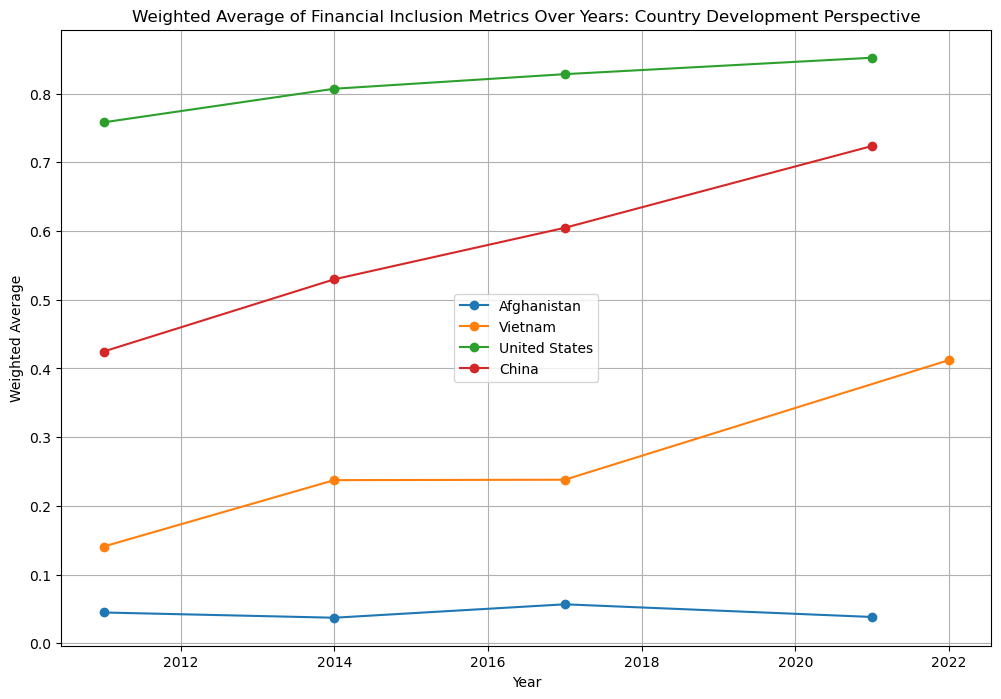

In [26]:
import matplotlib.pyplot as plt
countries = ['Afghanistan', 'Vietnam', 'United States', 'China']

plt.figure(figsize=(12, 8))

for country in countries:
    country_data = merged_df.xs(country)
    plt.plot(country_data.index, country_data['Weighted_Average'], marker='o', label=country)

plt.title('Weighted Average of Financial Inclusion Metrics Over Years: Country Development Perspective')
plt.xlabel('Year')
plt.ylabel('Weighted Average')
plt.legend()
plt.grid(True)
plt.show()


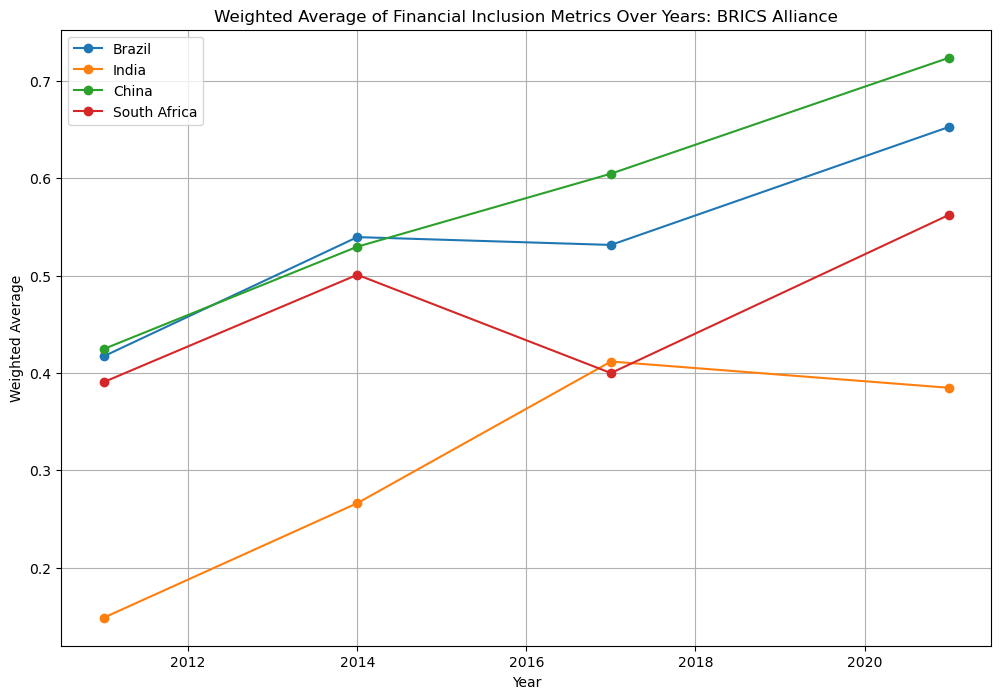

In [27]:
countries1 = ['Brazil', 'India', 'China', 'South Africa' ]

plt.figure(figsize=(12, 8))

for country in countries1:
    stuff = merged_df.xs(country)
    plt.plot(stuff.index, stuff['Weighted_Average'], marker='o', label=country)

plt.title('Weighted Average of Financial Inclusion Metrics Over Years: BRICS Alliance')
plt.xlabel('Year')
plt.ylabel('Weighted Average')
plt.legend()
plt.grid(True)
plt.show()

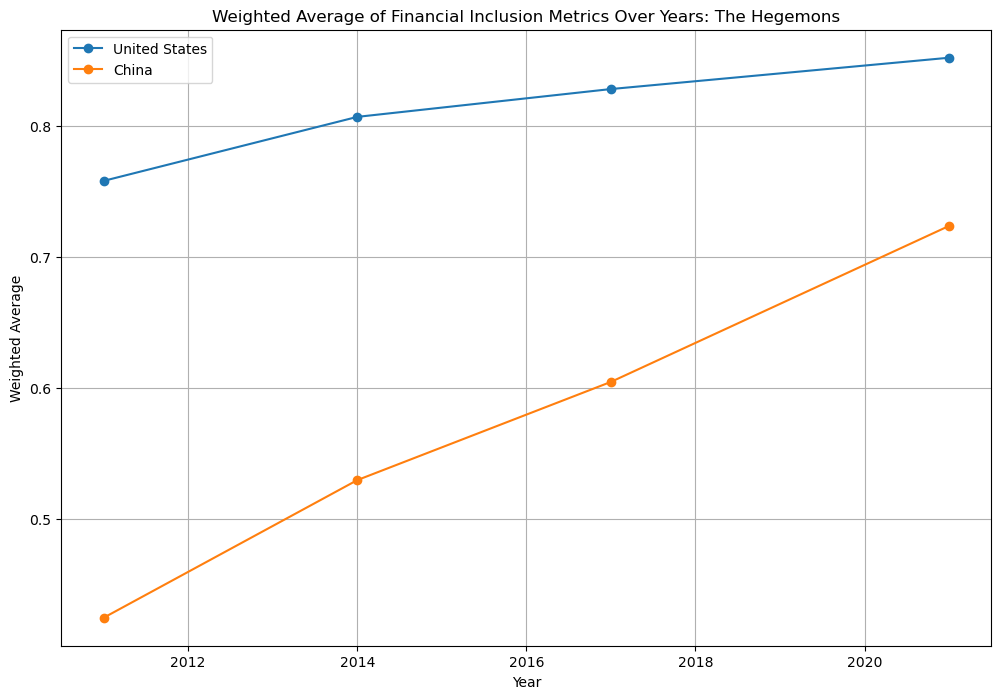

In [28]:
import matplotlib.pyplot as plt
countries = [ 'United States', 'China']

plt.figure(figsize=(12, 8))

for country in countries:
    country_data = merged_df.xs(country)
    plt.plot(country_data.index, country_data['Weighted_Average'], marker='o', label=country)

plt.title('Weighted Average of Financial Inclusion Metrics Over Years: The Hegemons')
plt.xlabel('Year')
plt.ylabel('Weighted Average')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
freedom_indicators = list(freedom_indices.columns)[5:]
freedom_indicators

['Political Rights Rating',
 'Civil Liberties Rating',
 'Electoral Process',
 'Political Pluralism and Participation',
 'Functioning of Government',
 'Political Rights category',
 'Freedom of Expression and Belief',
 'Associational and Organizational Rights',
 'Rule of Law',
 'Personal Autonomy and Individual Rights',
 'Civil Liberties category',
 'Total',
 'Total Freedom Ratio']

In [30]:
freedom_df = pd.merge(freedom_indices, df_cleaned, left_on=['Location Name', 'Edition'], right_on=['Country name', 'Year'])
freedom_df = freedom_df.groupby(['Location Name', 'Edition']).sum()
freedom_df

Region_x Country or Territory? Freedom Status  \
Location Name Edition                                                 
Afghanistan   2011        Asia                     c       Not Free   
              2014        Asia                     c       Not Free   
              2017        Asia                     c       Not Free   
              2021        Asia                     c       Not Free   
Albania       2011      Europe                     c    Partly Free   
...                        ...                   ...            ...   
Zambia        2021      Africa                     c    Partly Free   
Zimbabwe      2011      Africa                     c       Not Free   
              2014      Africa                     c       Not Free   
              2017      Africa                     c    Partly Free   
              2021      Africa                     c       Not Free   

                       Political Rights Rating  Civil Liberties Rating  \
Location Name Edition                                                    
Afghanistan   2011                           6                       6   
              2014                           6                       6   
              2017                           6                       6   
              2021                           5                       6   
Albania       2011                           3                       3   
...                                        ...                     ...   
Zambia        2021                           4                       4   
Zimbabwe      2011                           6                       6   
              2014                           5                       6   
              2017                           5                       5   
              2021                           6                       5   

                       Electoral Process  \
Location Name Edition                      
Afghanistan   2011                     3   
              2014                     3   
              2017                     2   
              2021                     3   
Albania       2011                     8   
...                                  ...   
Zambia        2021                     6   
Zimbabwe      2011                     2   
              2014                     3   
              2017                     3   
              2021                     3   

                       Political Pluralism and Participation  \
Location Name Edition                                          
Afghanistan   2011                                         6   
              2014                                         6   
              2017                                         6   
              2021                                         7   
Albania       2011                                        11   
...                                                      ...   
Zambia        2021                                        10   
Zimbabwe      2011                                         4   
              2014                                         6   
              2017                                         6   
              2021                                         5   

                       Functioning of Government  Political Rights category  \
Location Name Edition                                                         
Afghanistan   2011                             1                         10   
              2014                             2                         11   
              2017                             2                         10   
              2021                             3                         13   
Albania       2011                             7                         26   
...                                          ...                        ...   
Zambia        2021                             4                         20   
Zimbabwe      2011

In [31]:
freedom_df

Region_x Country or Territory? Freedom Status  \
Location Name Edition                                                 
Afghanistan   2011        Asia                     c       Not Free   
              2014        Asia                     c       Not Free   
              2017        Asia                     c       Not Free   
              2021        Asia                     c       Not Free   
Albania       2011      Europe                     c    Partly Free   
...                        ...                   ...            ...   
Zambia        2021      Africa                     c    Partly Free   
Zimbabwe      2011      Africa                     c       Not Free   
              2014      Africa                     c       Not Free   
              2017      Africa                     c    Partly Free   
              2021      Africa                     c       Not Free   

                       Political Rights Rating  Civil Liberties Rating  \
Location Name Edition                                                    
Afghanistan   2011                           6                       6   
              2014                           6                       6   
              2017                           6                       6   
              2021                           5                       6   
Albania       2011                           3                       3   
...                                        ...                     ...   
Zambia        2021                           4                       4   
Zimbabwe      2011                           6                       6   
              2014                           5                       6   
              2017                           5                       5   
              2021                           6                       5   

                       Electoral Process  \
Location Name Edition                      
Afghanistan   2011                     3   
              2014                     3   
              2017                     2   
              2021                     3   
Albania       2011                     8   
...                                  ...   
Zambia        2021                     6   
Zimbabwe      2011                     2   
              2014                     3   
              2017                     3   
              2021                     3   

                       Political Pluralism and Participation  \
Location Name Edition                                          
Afghanistan   2011                                         6   
              2014                                         6   
              2017                                         6   
              2021                                         7   
Albania       2011                                        11   
...                                                      ...   
Zambia        2021                                        10   
Zimbabwe      2011                                         4   
              2014                                         6   
              2017                                         6   
              2021                                         5   

                       Functioning of Government  Political Rights category  \
Location Name Edition                                                         
Afghanistan   2011                             1                         10   
              2014                             2                         11   
              2017                             2                         10   
              2021                             3                         13   
Albania       2011                             7                         26   
...                                          ...                        ...   
Zambia        2021                             4                         20   
Zimbabwe      2011

In [32]:
merged_df

Edition  Total Freedom Ratio Country code Adult populaiton  \
Location Name Year                                                              
Afghanistan   2011    2011                 0.25          AFG         15124473   
              2014    2014                 0.26          AFG         17300802   
              2017    2017                 0.24          AFG         19718214   
              2021    2021                 0.27          AFG         22647496   
Albania       2011    2011                 0.66          ALB          2258900   
...                    ...                  ...          ...              ...   
Zambia        2021    2021                 0.52          ZMB         10291819   
Zimbabwe      2011    2011                 0.21          ZWE          7414228   
              2014    2014                 0.28          ZWE          7712326   
              2017    2017                 0.32          ZWE          8044282   
              2021    2021                 0.28          ZWE          8633711   

                                                           Region  \
Location Name Year                                                  
Afghanistan   2011                                     South Asia   
              2014                                     South Asia   
              2017                                     South Asia   
              2021                                     South Asia   
Albania       2011  Europe & Central Asia (excluding high income)   
...                                                           ...   
Zambia        2021     Sub-Saharan Africa (excluding high income)   
Zimbabwe      2011     Sub-Saharan Africa (excluding high income)   
              2014     Sub-Saharan Africa (excluding high income)   
              2017     Sub-Saharan Africa (excluding high income)   
              2021     Sub-Saharan Africa (excluding high income)   

                   Account (% age 15+)  \
Location Name Year                       
Afghanistan   2011                0.09   
              2014                 0.1   
              2017                0.15   
              2021                 0.1   
Albania       2011                0.28   
...                                ...   
Zambia        2021                0.49   
Zimbabwe      2011                 0.4   
              2014                0.32   
              2017                0.55   
              2021                 0.6   

                   Financial institution account (% age 15+)  \
Location Name Year                                             
Afghanistan   2011                                      0.09   
              2014                                       0.1   
              2017                                      0.15   
              2021                                       0.1   
Albania       2011                                      0.28   
...                                                      ...   
Zambia        2021                                      0.24   
Zimbabwe      2011                                       0.4   
              2014                                      0.17   
              2017                                      0.28   
              2021                                      0.29   

                   Owns a credit card (% age 15+)  \
Location Name Year                                  
Afghanistan   2011                           0.01   
              2014                           0.01   
              2017                           0.01   
              2021                            0.0   
Albania       2011                           0.11   
...                                           ...   
Zambia        2021                           0.02   
Zimbabwe      2011                           0.06   
              2014                           0.02   
              2017                           0.01   
              2021                            0.0  

In [33]:
merged_df_reindexed = merged_df.reindex(freedom_df.index)
freedom_df['Weighted_Average'] = merged_df_reindexed['Weighted_Average']
freedom_df

Region_x Country or Territory? Freedom Status  \
Location Name Edition                                                 
Afghanistan   2011        Asia                     c       Not Free   
              2014        Asia                     c       Not Free   
              2017        Asia                     c       Not Free   
              2021        Asia                     c       Not Free   
Albania       2011      Europe                     c    Partly Free   
...                        ...                   ...            ...   
Zambia        2021      Africa                     c    Partly Free   
Zimbabwe      2011      Africa                     c       Not Free   
              2014      Africa                     c       Not Free   
              2017      Africa                     c    Partly Free   
              2021      Africa                     c       Not Free   

                       Political Rights Rating  Civil Liberties Rating  \
Location Name Edition                                                    
Afghanistan   2011                           6                       6   
              2014                           6                       6   
              2017                           6                       6   
              2021                           5                       6   
Albania       2011                           3                       3   
...                                        ...                     ...   
Zambia        2021                           4                       4   
Zimbabwe      2011                           6                       6   
              2014                           5                       6   
              2017                           5                       5   
              2021                           6                       5   

                       Electoral Process  \
Location Name Edition                      
Afghanistan   2011                     3   
              2014                     3   
              2017                     2   
              2021                     3   
Albania       2011                     8   
...                                  ...   
Zambia        2021                     6   
Zimbabwe      2011                     2   
              2014                     3   
              2017                     3   
              2021                     3   

                       Political Pluralism and Participation  \
Location Name Edition                                          
Afghanistan   2011                                         6   
              2014                                         6   
              2017                                         6   
              2021                                         7   
Albania       2011                                        11   
...                                                      ...   
Zambia        2021                                        10   
Zimbabwe      2011                                         4   
              2014                                         6   
              2017                                         6   
              2021                                         5   

                       Functioning of Government  Political Rights category  \
Location Name Edition                                                         
Afghanistan   2011                             1                         10   
              2014                             2                         11   
              2017                             2                         10   
              2021                             3                         13   
Albania       2011                             7                         26   
...                                          ...                        ...   
Zambia        2021                             4                         20   
Zimbabwe      2011

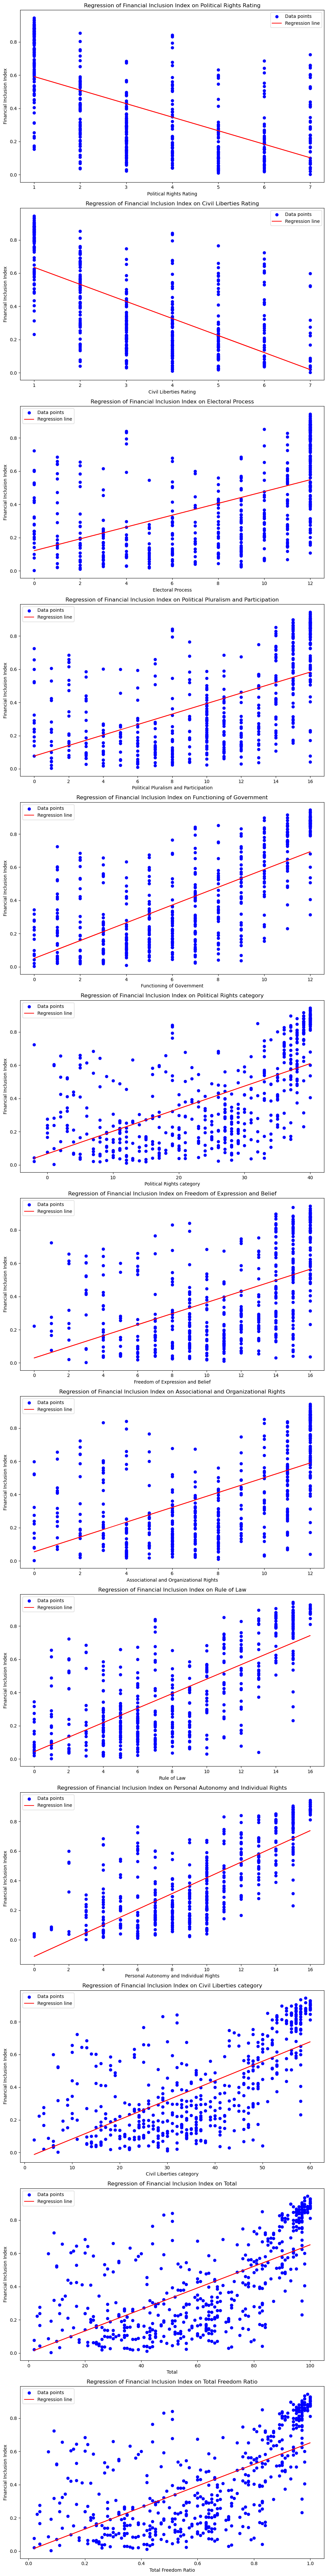

,Dependent Variable,Independent Variable,R-squared,Overall model p-value,Coef_const,p-value_const
9,Weighted_Average,Personal Autonomy and Individual Rights,0.563561,4.696431e-94,-0.112719,2.782785e-07
8,Weighted_Average,Rule of Law,0.510549,2.590202e-81,0.043427,1.486052e-02
4,Weighted_Average,Functioning of Government,0.465739,1.423939e-71,0.050866,7.439842e-03
10,Weighted_Average,Civil Liberties category,0.443813,4.234339e-67,-0.035853,1.289692e-01
1,Weighted_Average,Civil Liberties Rating,0.423245,4.637394e-63,0.737673,8.693677e-150
11,Weighted_Average,Total,0.415012,1.751075e-61,0.002534,9.124273e-01
12,Weighted_Average,Total Freedom Ratio,0.415012,1.751075e-61,0.002534,9.124273e-01
5,Weighted_Average,Political Rights category,0.361127,1.123750e-51,0.066674,2.656843e-03
0,Weighted_Average,Political Rights Rating,0.360591,1.392983e-51,0.672891,4.276227e-143
7,Weighted_Average,Associational and Organizational Rights,0.339098,6.695378e-48,0.054567,2.180163e-02


In [34]:
import pandas as pd
import statsmodels.api as sm

# Assuming freedom_df and freedom_indicators are already defined

Y = freedom_df['Weighted_Average']
aLists = []

fig, axes = plt.subplots(nrows=len(freedom_indicators), ncols=1, figsize=(10, 6 * len(freedom_indicators)))

for i, x_var in enumerate(freedom_indicators):
    X_stuff = freedom_df[x_var]
    X = pd.to_numeric(X_stuff, errors='coerce').dropna()  # Convert X_stuff to numeric and drop NaNs

    # Get common index between X and Y
    common_index = X.index.intersection(Y.index)
    X_common = X.loc[common_index]
    Y_common = Y.loc[common_index]

    if len(X_common) == 0 or len(Y_common) == 0:
        print(f"Skipping {x_var} due to insufficient data after cleaning.")
        continue

    Y_common = pd.to_numeric(Y_common, errors='coerce')
    X_common = X_common.apply(pd.to_numeric, errors='coerce')
    
    # Drop rows with NaN values in either Y_common or X_common
    Y_common = Y_common.dropna()
    X_common = X_common.dropna()
    
    # Ensure both Y_common and X_common have the same indices after dropping NaNs
    common_indices = Y_common.index.intersection(X_common.index)
    Y_common = Y_common.loc[common_indices]
    X_common = X_common.loc[common_indices]

    X_common = sm.add_constant(X_common)  # Add constant to X_common
    model = sm.OLS(Y_common, X_common).fit()

    r_squared = model.rsquared
    p_value = model.f_pvalue  # Overall model p-value
    coefficients = model.params
    p_values = model.pvalues

    result1 = {
        'Dependent Variable': 'Weighted_Average',
        'Independent Variable': x_var,
        'R-squared': r_squared,
        'Overall model p-value': p_value,
    }

    for idx in range(len(coefficients)):
        result1[f'Coef_{coefficients.index[idx]}'] = coefficients.iloc[idx]
        result1[f'p-value_{coefficients.index[idx]}'] = p_values.iloc[idx]

    aLists.append(result1)

    # Plotting
    axes[i].scatter(X_common.iloc[:, 1], Y_common, color='blue', label='Data points')  # X_common.iloc[:, 1] skips the constant column
    axes[i].plot(X_common.iloc[:, 1], model.predict(X_common), color='red', label='Regression line')
    axes[i].set_xlabel(x_var)
    axes[i].set_ylabel('Financial Inclusion Index')
    axes[i].set_title(f'Regression of Financial Inclusion Index on {x_var}')
    axes[i].legend()

# Adjust layout
plt.tight_layout()
plt.show()

# Convert results to a DataFrame for better display
results_df = pd.DataFrame(aLists)
results_df = results_df.iloc[:, :6]
results_df.sort_values(by = 'R-squared', ascending = False)

In [35]:
results_df = results_df[:-1]

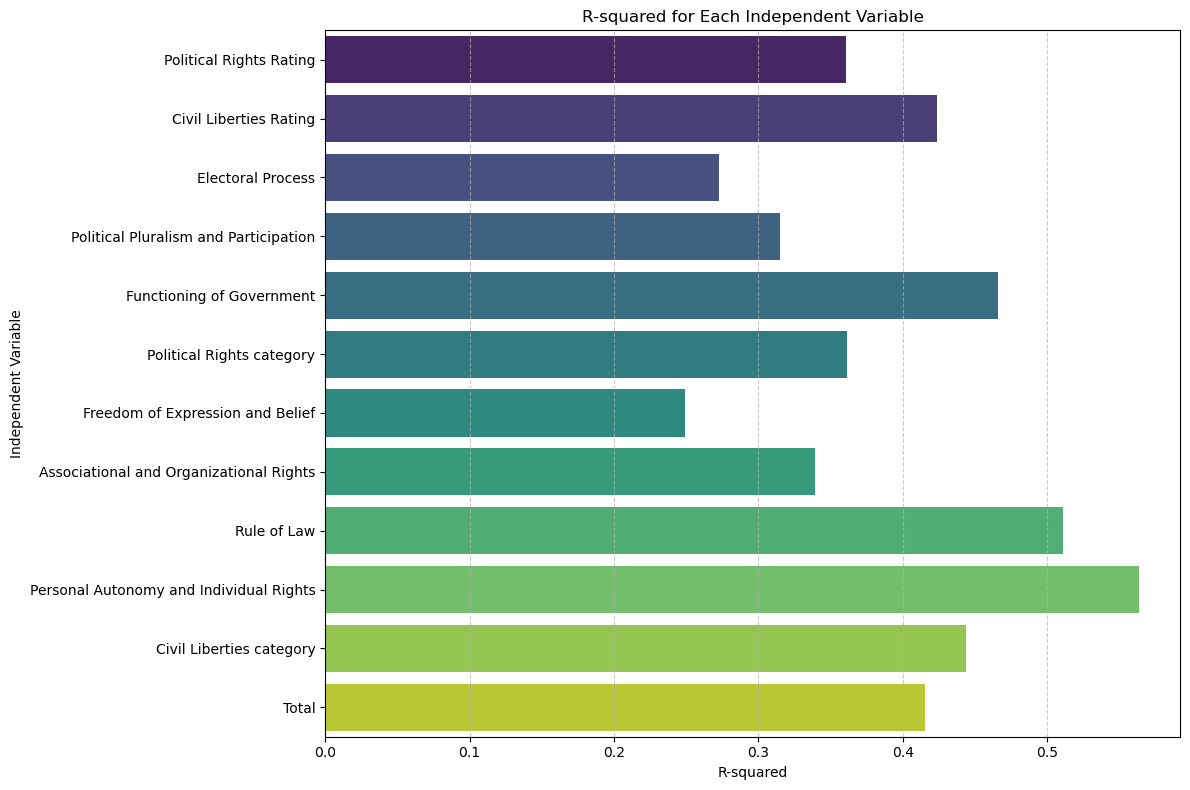

In [36]:
ppol = results_df[['Independent Variable', 'R-squared']]

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(
    data=ppol,
    x='R-squared',
    y='Independent Variable',
    palette='viridis'
)

plt.xlabel('R-squared')
plt.ylabel('Independent Variable')
plt.title('R-squared for Each Independent Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

In [37]:
with open("grade.csv",'r') as infile:
    text = list(csv.reader(infile))
    header = text[0]
    data = text[1:]

states = data
states_df = pd.DataFrame(states, columns=header)
aCopy = states_df
# grouped = states_df.groupby(['Region', 'Country/Territory']).sum()
states_df.set_index(['Region', 'Country/Territory'], inplace=True)

In [38]:
twentyfour = states_df[states_df['Edition'] == '2024']

grade_mapping = {'A': 4, 'B': 3, 'C': 2, 'D': 1}
twentyfour['NumericGrade'] = twentyfour['grade'].map(grade_mapping)

# # Group by 'Region' and calculate the mean numeric grade
grouped_df = twentyfour.groupby('Region')['NumericGrade'].mean()
grouped_df

C:\Users\Shivani Murugapiran\AppData\Local\Temp\ipykernel_25972\2775298301.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  twentyfour['NumericGrade'] = twentyfour['grade'].map(grade_mapping)


Region
Africa         3.625000
Americas       3.942857
Asia           3.813953
Eurasia        3.444444
Europe         4.000000
Middle East    3.533333
Name: NumericGrade, dtype: float64

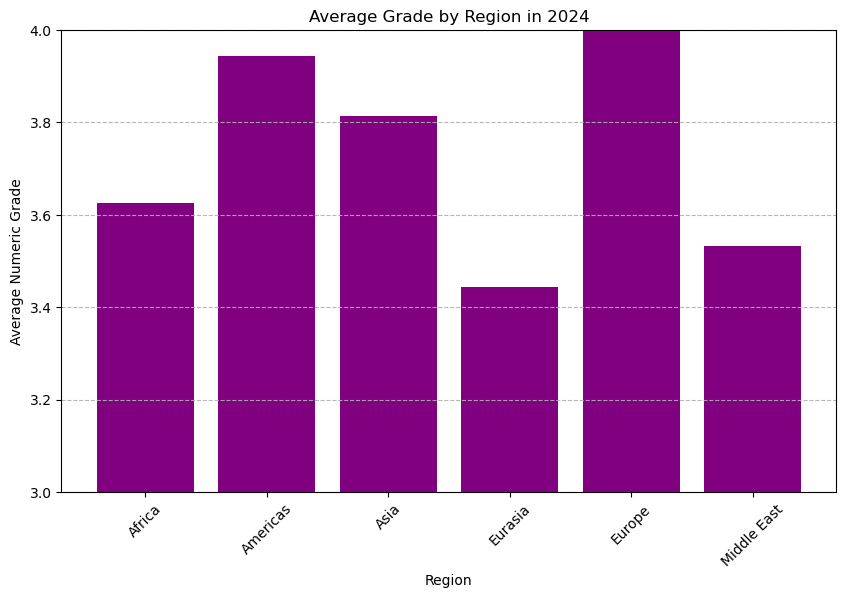

In [39]:
# Plotting
plt.figure(figsize=(10, 6))
plt.bar(grouped_df.index, grouped_df, color='purple')
plt.xlabel('Region')
plt.ylabel('Average Numeric Grade')
plt.title('Average Grade by Region in 2024')
plt.xticks(rotation=45)
plt.ylim(3, 4)
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.show()


#

In [40]:

twenty14 = aCopy[aCopy['Edition'] == '2014']

grade_mapping = {'A': 4, 'B': 3, 'C': 2, 'D': 1}
twenty14['NumericGrade'] = twenty14['grade'].map(grade_mapping)

# # # Group by 'Region' and calculate the mean numeric grade
grouped_df1 = twenty14.groupby('Region')['NumericGrade'].mean()
grouped_df1

C:\Users\Shivani Murugapiran\AppData\Local\Temp\ipykernel_25972\1768084166.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  twenty14['NumericGrade'] = twenty14['grade'].map(grade_mapping)


Region
Africa         3.750000
Americas       4.000000
Asia           3.906977
Eurasia        3.750000
Europe         4.000000
Middle East    3.533333
Name: NumericGrade, dtype: float64

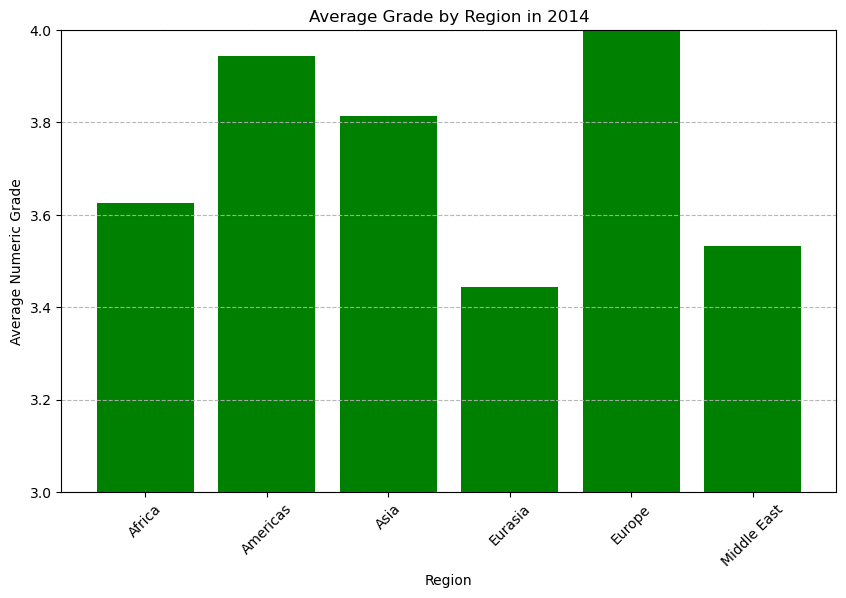

In [41]:
plt.figure(figsize=(10, 6))
plt.bar(grouped_df1.index, grouped_df, color='green')
plt.xlabel('Region')
plt.ylabel('Average Numeric Grade')
plt.title('Average Grade by Region in 2014')
plt.xticks(rotation=45)
plt.ylim(3, 4)
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.show()

In [42]:
okay = pd.merge(grouped_df, grouped_df1, on='Region')
okay

,NumericGrade_x,NumericGrade_y
Region,,
Africa,3.625000,3.750000
Americas,3.942857,4.000000
Asia,3.813953,3.906977
Eurasia,3.444444,3.750000
Europe,4.000000,4.000000
Middle East,3.533333,3.533333


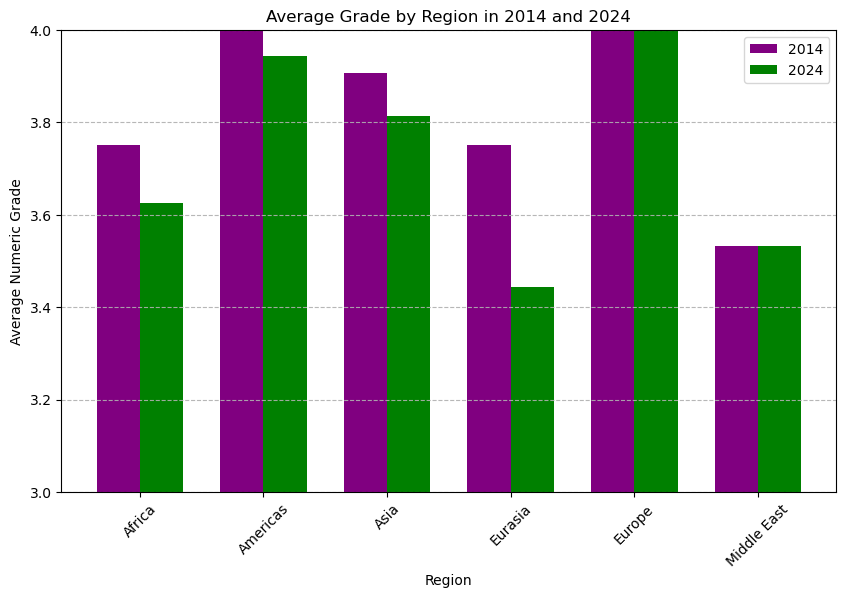

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35  # the width of the bars

# Create bar positions
x = range(len(okay.index))
x_2014 = [i - width/2 for i in x]
x_2024 = [i + width/2 for i in x]

# Plot bars
ax.bar(x_2014, okay['NumericGrade_y'], width, label='2014', color='purple')
ax.bar(x_2024, okay['NumericGrade_x'], width, label='2024', color='green')

# Labels and Title
ax.set_xlabel('Region')
ax.set_ylabel('Average Numeric Grade')
ax.set_title('Average Grade by Region in 2014 and 2024')
ax.set_xticks(x)
ax.set_xticklabels(okay.index, rotation=45)
ax.set_ylim(3, 4)  # Change the y-axis range to be from 3 to 4
ax.grid(axis='y', linestyle='--', alpha=0.9)

# Add legend
ax.legend()

plt.show()

In [44]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
aList[1:-1]

['Political Rights Rating',
 'Civil Liberties Rating',
 'Electoral Process',
 'Political Pluralism and Participation',
 'Functioning of Government',
 'Political Rights category',
 'Freedom of Expression and Belief',
 'Associational and Organizational Rights',
 'Rule of Law',
 'Personal Autonomy and Individual Rights',
 'Civil Liberties category',
 'Total']

In [45]:
# Y = freedom_df['Weighted_Average']
# X = freedom_df[['Political Rights Rating',
#  'Civil Liberties Rating',
#  'Electoral Process',
#  'Political Pluralism and Participation',
#  'Functioning of Government',
#  'Political Rights category',
#  'Freedom of Expression and Belief',
#  'Associational and Organizational Rights',
#  'Rule of Law',
#  'Personal Autonomy and Individual Rights',
#  'Civil Liberties category',
#  'Total']]
# param_grid = {
#     'polynomialfeatures__degree': np.arange(21),
#     'linearregression__fit_intercept': [True, False]
# }
# pipeline = Pipeline([
#     ('polynomialfeatures', PolynomialFeatures()),
#     ('linearregression', LinearRegression())
# ])
# grid = GridSearchCV(pipeline, param_grid, cv=5, verbose=1)
# grid.fit(X, Y)
# best_params = grid.best_params_
# best_model = grid.best_estimator_

# print("Best Parameters:", best_params)
# print("Best Model:", best_model)

# pd.DataFrame(grid.cv_results_)